In [1]:
# import python libraries

import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt # visualizing data
%matplotlib inline
import seaborn as sns

In [2]:
# import csv file
df = pd.read_csv('../data/sales_analysis_data.csv', encoding='unicode_escape')

In [3]:
df.shape

(11251, 15)

In [4]:
df.head()

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount,Status,unnamed1
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.0,NaN,NaN
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.0,NaN,NaN
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.0,NaN,NaN
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.0,NaN,NaN
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.0,NaN,NaN


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11251 entries, 0 to 11250
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           11251 non-null  int64  
 1   Cust_name         11251 non-null  str    
 2   Product_ID        11251 non-null  str    
 3   Gender            11251 non-null  str    
 4   Age Group         11251 non-null  str    
 5   Age               11251 non-null  int64  
 6   Marital_Status    11251 non-null  int64  
 7   State             11251 non-null  str    
 8   Zone              11251 non-null  str    
 9   Occupation        11251 non-null  str    
 10  Product_Category  11251 non-null  str    
 11  Orders            11251 non-null  int64  
 12  Amount            11239 non-null  float64
 13  Status            0 non-null      float64
 14  unnamed1          0 non-null      float64
dtypes: float64(3), int64(4), str(8)
memory usage: 1.3 MB


In [6]:
#drop unrelated/blank columns
df.drop(['Status', 'unnamed1'], axis=1, inplace=True)#drop unrelated/blank columns


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11251 entries, 0 to 11250
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           11251 non-null  int64  
 1   Cust_name         11251 non-null  str    
 2   Product_ID        11251 non-null  str    
 3   Gender            11251 non-null  str    
 4   Age Group         11251 non-null  str    
 5   Age               11251 non-null  int64  
 6   Marital_Status    11251 non-null  int64  
 7   State             11251 non-null  str    
 8   Zone              11251 non-null  str    
 9   Occupation        11251 non-null  str    
 10  Product_Category  11251 non-null  str    
 11  Orders            11251 non-null  int64  
 12  Amount            11239 non-null  float64
dtypes: float64(1), int64(4), str(8)
memory usage: 1.1 MB


In [8]:
#check for null values
pd.isnull(df).sum()

User_ID              0
Cust_name            0
Product_ID           0
Gender               0
Age Group            0
Age                  0
Marital_Status       0
State                0
Zone                 0
Occupation           0
Product_Category     0
Orders               0
Amount              12
dtype: int64

In [9]:
# drop null values
df.dropna(inplace=True)

In [10]:
df.info()

<class 'pandas.DataFrame'>
Index: 11239 entries, 0 to 11250
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           11239 non-null  int64  
 1   Cust_name         11239 non-null  str    
 2   Product_ID        11239 non-null  str    
 3   Gender            11239 non-null  str    
 4   Age Group         11239 non-null  str    
 5   Age               11239 non-null  int64  
 6   Marital_Status    11239 non-null  int64  
 7   State             11239 non-null  str    
 8   Zone              11239 non-null  str    
 9   Occupation        11239 non-null  str    
 10  Product_Category  11239 non-null  str    
 11  Orders            11239 non-null  int64  
 12  Amount            11239 non-null  float64
dtypes: float64(1), int64(4), str(8)
memory usage: 1.2 MB


In [11]:
# change data type
df['Amount'] = df['Amount'].astype('int')

In [12]:
total_revenue = df['Amount'].sum()
print("Total Revenue:", total_revenue)

Total Revenue: 106249129


In [13]:
df['Amount'].dtypes

dtype('int64')

In [14]:
df.columns

Index(['User_ID', 'Cust_name', 'Product_ID', 'Gender', 'Age Group', 'Age',
       'Marital_Status', 'State', 'Zone', 'Occupation', 'Product_Category',
       'Orders', 'Amount'],
      dtype='str')

In [15]:
print("📊 KPI SUMMARY")
print("-" * 40)

total_revenue = df['Amount'].sum()
total_orders = df['Orders'].sum()
avg_order_value = total_revenue / total_orders

top_gender = df.groupby('Gender')['Amount'].sum().idxmax()
top_age_group = df.groupby('Age Group')['Amount'].sum().idxmax()
top_state = df.groupby('State')['Amount'].sum().idxmax()
top_category = df.groupby('Product_Category')['Amount'].sum().idxmax()
top_occupation = df.groupby('Occupation')['Amount'].sum().idxmax()

print(f"Total Revenue: {total_revenue}")
print(f"Total Orders: {total_orders}")
print(f"Avg Order Value: {round(avg_order_value,2)}")
print(f"Top Gender: {top_gender}")
print(f"Top Age Group: {top_age_group}")
print(f"Top State: {top_state}")
print(f"Top Category: {top_category}")
print(f"Top Occupation: {top_occupation}")

📊 KPI SUMMARY
----------------------------------------
Total Revenue: 106249129
Total Orders: 27981
Avg Order Value: 3797.19
Top Gender: F
Top Age Group: 26-35
Top State: Uttar Pradesh
Top Category: Food
Top Occupation: IT Sector


In [16]:
total_orders = df['Orders'].sum()
avg_order_value = total_revenue / total_orders

print("Average Order Value:", round(avg_order_value, 2))

Average Order Value: 3797.19


In [17]:
top_gender = df.groupby('Gender')['Amount'].sum().sort_values(ascending=False)
print(top_gender)
print("Top Gender Segment:", top_gender.idxmax())

Gender
F    74335853
M    31913276
Name: Amount, dtype: int64
Top Gender Segment: F


In [18]:
top_age_group = df.groupby('Age Group')['Amount'].sum().sort_values(ascending=False)
print("Top Age Group:", top_age_group.idxmax())

Top Age Group: 26-35


In [19]:
top_state = df.groupby('State')['Amount'].sum().sort_values(ascending=False)
print("Top State:", top_state.idxmax())

Top State: Uttar Pradesh


In [20]:
top_category = df.groupby('Product_Category')['Amount'].sum().sort_values(ascending=False)
print("Top Category:", top_category.idxmax())

Top Category: Food


In [21]:
gender_sales = df.groupby('Gender')['Amount'].sum()

gender_contribution = (gender_sales / total_revenue) * 100

print(gender_contribution.round(2))

Gender
F    69.96
M    30.04
Name: Amount, dtype: float64


In [22]:
state_sales = df.groupby('State')['Amount'].sum()

state_contribution = (state_sales / total_revenue) * 100

print(state_contribution.sort_values(ascending=False).round(2))

State
Uttar Pradesh       18.24
Maharashtra         13.58
Karnataka           12.73
Delhi               10.92
Madhya Pradesh       7.62
Andhra Pradesh       7.56
Himachal Pradesh     4.67
Haryana              3.97
Bihar                3.79
Gujarat              3.71
Kerala               3.67
Jharkhand            2.85
Uttarakhand          2.37
Rajasthan            1.80
Punjab               1.44
Telangana            1.08
Name: Amount, dtype: float64


In [23]:
#rename column
df.rename(columns= {'Marital_Status':'Married/Single'})

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Married/Single,State,Zone,Occupation,Product_Category,Orders,Amount
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877
...,...,...,...,...,...,...,...,...,...,...,...,...,...
11246,1000695,Manning,P00296942,M,18-25,19,1,Maharashtra,Western,Chemical,Office,4,370
11247,1004089,Reichenbach,P00171342,M,26-35,33,0,Haryana,Northern,Healthcare,Veterinary,3,367
11248,1001209,Oshin,P00201342,F,36-45,40,0,Madhya Pradesh,Central,Textile,Office,4,213
11249,1004023,Noonan,P00059442,M,36-45,37,0,Karnataka,Southern,Agriculture,Office,3,206


In [24]:
# describe() method returns description of the data in the DataFrame (i.e. count, mean, std, etc)
df.describe()

,User_ID,Age,Marital_Status,Orders,Amount
count,1.123900e+04,11239.000000,11239.000000,11239.000000,11239.000000
mean,1.003004e+06,35.410357,0.420055,2.489634,9453.610553
std,1.716039e+03,12.753866,0.493589,1.114967,5222.355168
min,1.000001e+06,12.000000,0.000000,1.000000,188.000000
25%,1.001492e+06,27.000000,0.000000,2.000000,5443.000000
50%,1.003064e+06,33.000000,0.000000,2.000000,8109.000000
75%,1.004426e+06,43.000000,1.000000,3.000000,12675.000000
max,1.006040e+06,92.000000,1.000000,4.000000,23952.000000


In [25]:
# use describe() for specific columns
df[['Age', 'Orders', 'Amount']].describe()

,Age,Orders,Amount
count,11239.000000,11239.000000,11239.000000
mean,35.410357,2.489634,9453.610553
std,12.753866,1.114967,5222.355168
min,12.000000,1.000000,188.000000
25%,27.000000,2.000000,5443.000000
50%,33.000000,2.000000,8109.000000
75%,43.000000,3.000000,12675.000000
max,92.000000,4.000000,23952.000000


# Exploratory Data Analysis

### Gender

<Axes: xlabel='Gender', ylabel='count'>

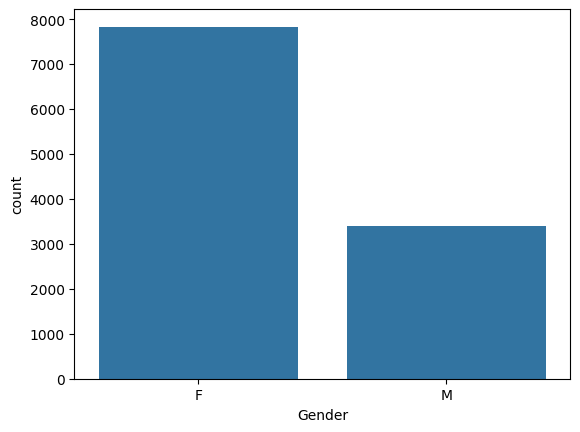

In [26]:
 sns.countplot(x = 'Gender',data = df)

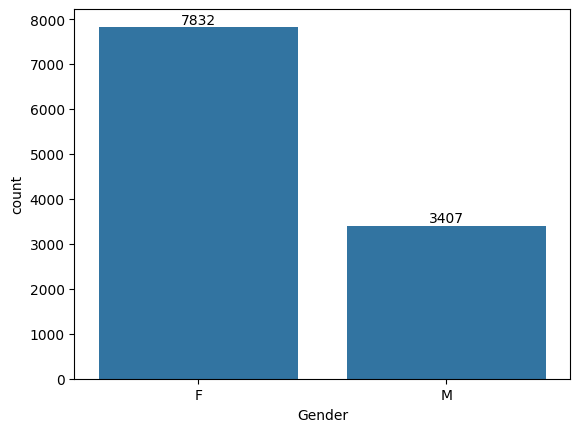

In [27]:
# plotting a bar chart for Gender and it's count

ax = sns.countplot(x = 'Gender',data = df)

for bars in ax.containers:
    ax.bar_label(bars)

In [28]:
df.groupby(['Gender'], as_index=False)['Amount'].sum().sort_values(by='Amount', ascending=False)

,Gender,Amount
0,F,74335853
1,M,31913276


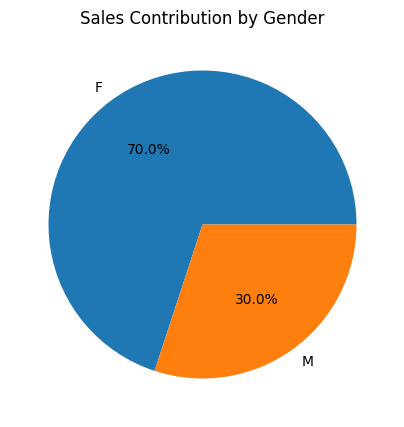

In [29]:
gender_sales = df.groupby('Gender')['Amount'].sum()

plt.figure(figsize=(5,5))
plt.pie(gender_sales, labels=gender_sales.index, autopct='%1.1f%%')
plt.title('Sales Contribution by Gender')
plt.show()

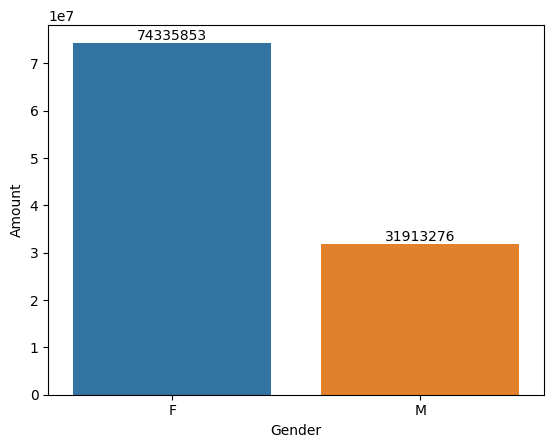

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

sales_gen = df.groupby(['Gender'], as_index=False)['Amount'].sum().sort_values(by='Amount', ascending=False)

ax = sns.barplot(x='Gender', y='Amount', data=sales_gen, hue = 'Gender')

# Optional: Add bar labels in normal scale
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f')  # shows normal numbers

plt.show()

<Axes: xlabel='Gender', ylabel='Amount'>

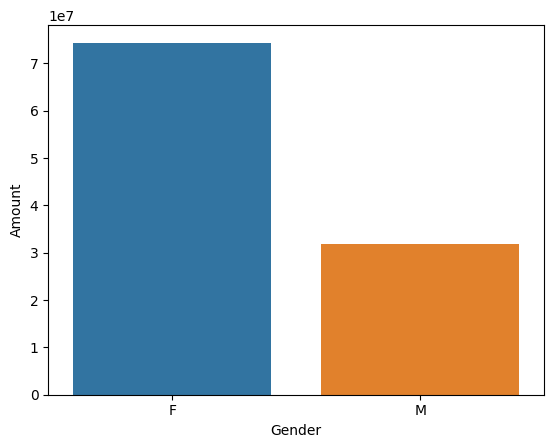

In [31]:
# plotting a bar chart for gender vs total amount

sales_gen = df.groupby(['Gender'], as_index=False)['Amount'].sum().sort_values(by='Amount', ascending=False)

sns.barplot(x = 'Gender',y= 'Amount' ,data = sales_gen, hue = 'Gender')


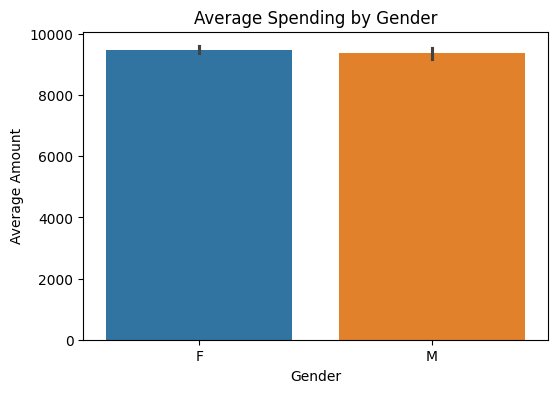

In [32]:
plt.figure(figsize=(6, 4))
sns.barplot(data=df, x='Gender', y='Amount', hue='Gender', estimator='mean', legend=False)

plt.title('Average Spending by Gender')
plt.xlabel('Gender')
plt.ylabel('Average Amount')
plt.show()

*From above graphs we can see that most of the buyers are females and even the purchasing power of females are greater than men*

### Age

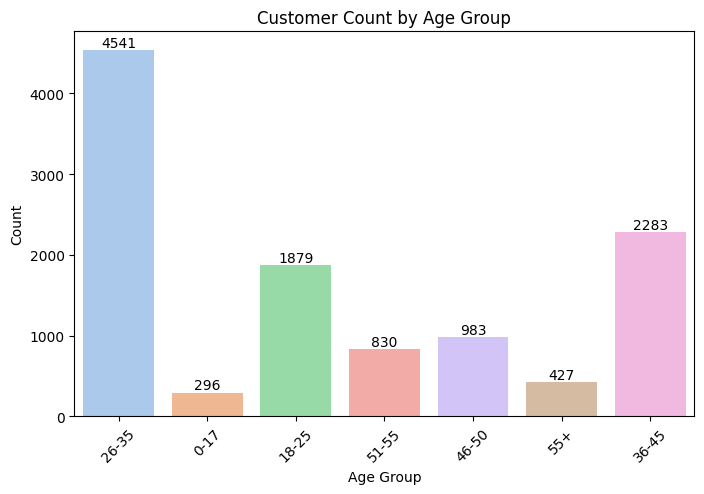

In [33]:
plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=df,
    x='Age Group', hue='Age Group', legend=False,
    palette='pastel'
)

for bars in ax.containers:
    ax.bar_label(bars)

plt.title('Customer Count by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

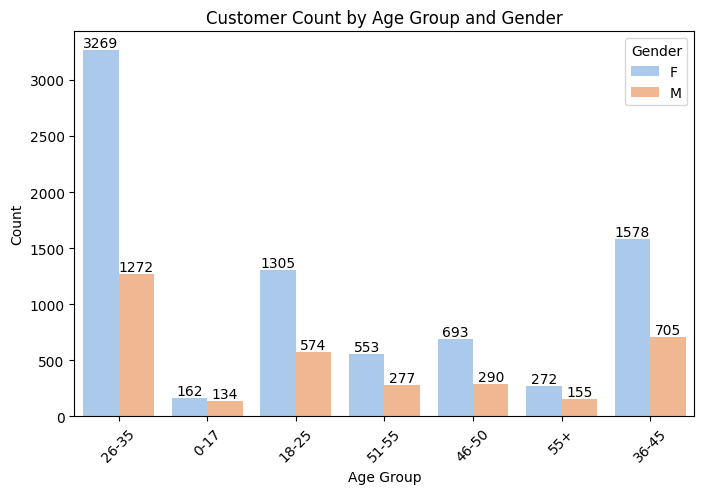

In [34]:
plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=df,
    x='Age Group',
    hue='Gender',
    palette='pastel'
)

for bars in ax.containers:
    ax.bar_label(bars)

plt.title('Customer Count by Age Group and Gender')
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

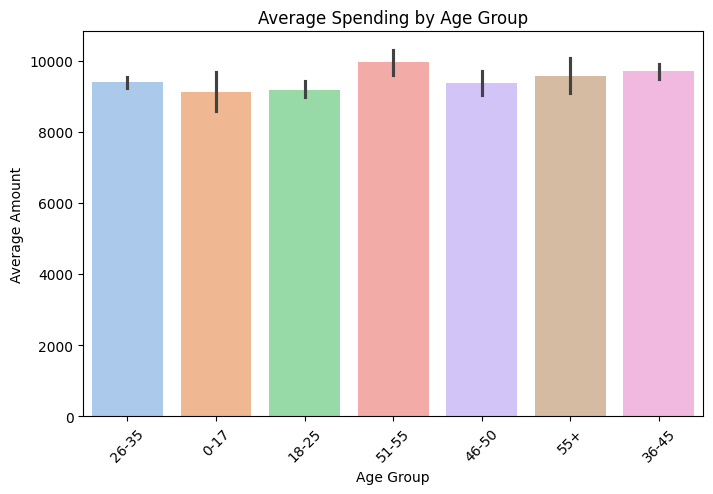

In [35]:
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=df,
    x='Age Group',
    y='Amount', hue='Age Group', legend=False,
    palette='pastel'
)

plt.title('Average Spending by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Average Amount')
plt.xticks(rotation=45)
plt.show()

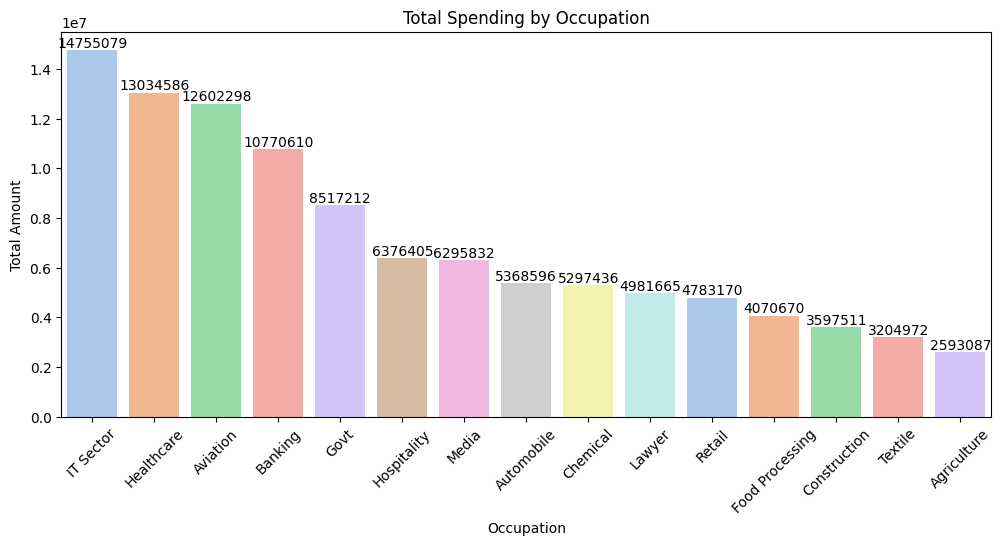

In [36]:
sales_occupation = (
    df.groupby('Occupation', as_index=False)['Amount']
      .sum()
      .sort_values(by='Amount', ascending=False)
)

plt.figure(figsize=(12, 5))

ax = sns.barplot(
    data=sales_occupation,
    x='Occupation',
    y='Amount',
    palette='pastel',
    hue='Occupation',
    legend=False
)

for bars in ax.containers:
    ax.bar_label(bars, fmt='%.0f')

plt.title('Total Spending by Occupation')
plt.xlabel('Occupation')
plt.ylabel('Total Amount')
plt.xticks(rotation=45)
plt.show()

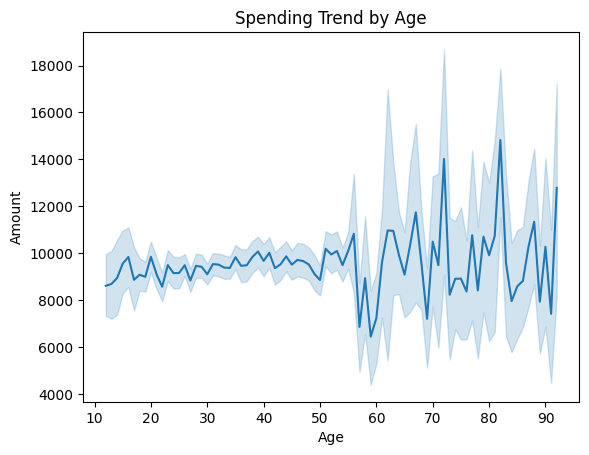

In [37]:
sns.lineplot(data=df, x='Age', y='Amount')
plt.title('Spending Trend by Age')
plt.show()

In [38]:
df.columns

Index(['User_ID', 'Cust_name', 'Product_ID', 'Gender', 'Age Group', 'Age',
       'Marital_Status', 'State', 'Zone', 'Occupation', 'Product_Category',
       'Orders', 'Amount'],
      dtype='str')

In [39]:
df.Amount.sum()

np.int64(106249129)

In [40]:
df.groupby(['Age Group'])['Amount']

In [41]:
df.groupby(['Age Group'])['Amount'].sum()

Age Group
0-17      2699653
18-25    17240732
26-35    42613442
36-45    22144994
46-50     9207844
51-55     8261477
55+       4080987
Name: Amount, dtype: int64

In [42]:
df.groupby(['Age Group'], as_index=False)['Amount'].sum()

,Age Group,Amount
0,0-17,2699653
1,18-25,17240732
2,26-35,42613442
3,36-45,22144994
4,46-50,9207844
5,51-55,8261477
6,55+,4080987


In [43]:
df.groupby(['Age Group'], as_index=False)['Amount'].sum().sort_values(by='Amount', ascending=False)

,Age Group,Amount
2,26-35,42613442
3,36-45,22144994
1,18-25,17240732
4,46-50,9207844
5,51-55,8261477
6,55+,4080987
0,0-17,2699653


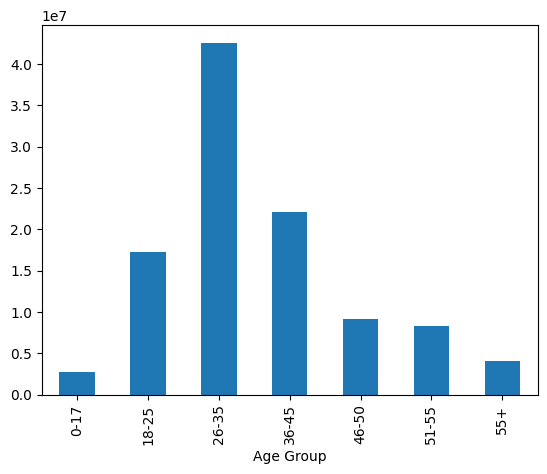

In [44]:

df.groupby('Age Group')['Amount'].sum().plot(kind='bar')
plt.show()

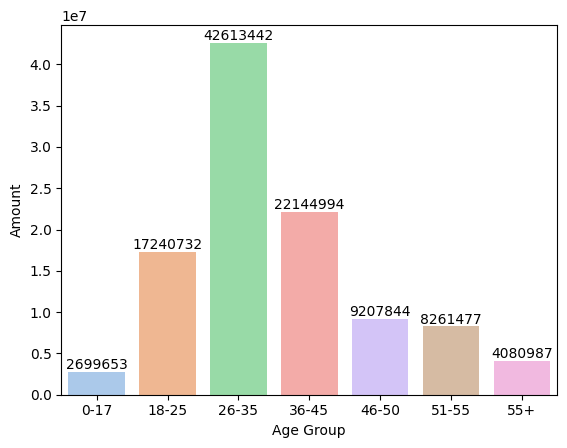

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

# Grouped data
sales_age = df.groupby(['Age Group'], as_index=False)['Amount'].sum()

# Plot and assign the Axes object to a variable
ax = sns.barplot(x='Age Group', y='Amount', data=sales_age, hue='Age Group', palette='pastel', legend=False)

# Add labels on top of bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f')  # fmt removes decimals
    

*From above graphs we can see that most of the buyers are of age group between 26-35 yrs female*

### State

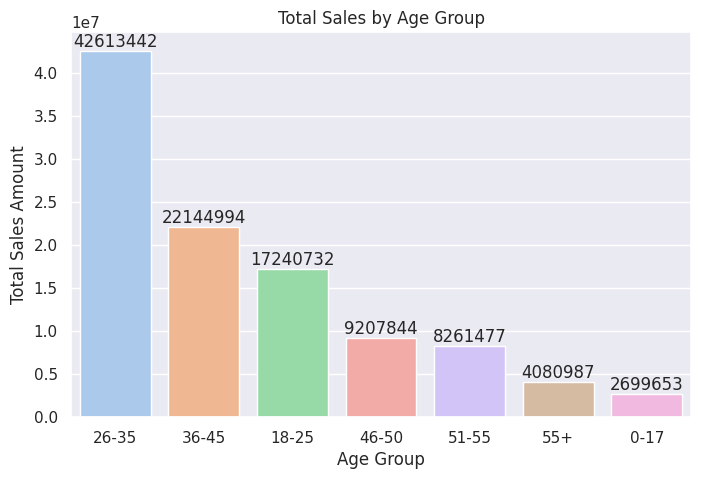

In [46]:
sales_age = (
    df.groupby('Age Group', as_index=False)['Amount']
      .sum()
      .sort_values(by='Amount', ascending=False)
)

sns.set(rc={'figure.figsize': (8, 5)})

ax = sns.barplot(
    data=sales_age,
    x='Age Group',
    y='Amount',
    palette='pastel',
    hue='Age Group',
    legend=False
)

for bars in ax.containers:
    ax.bar_label(bars, fmt='%.0f')

plt.title('Total Sales by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Total Sales Amount')
plt.show()

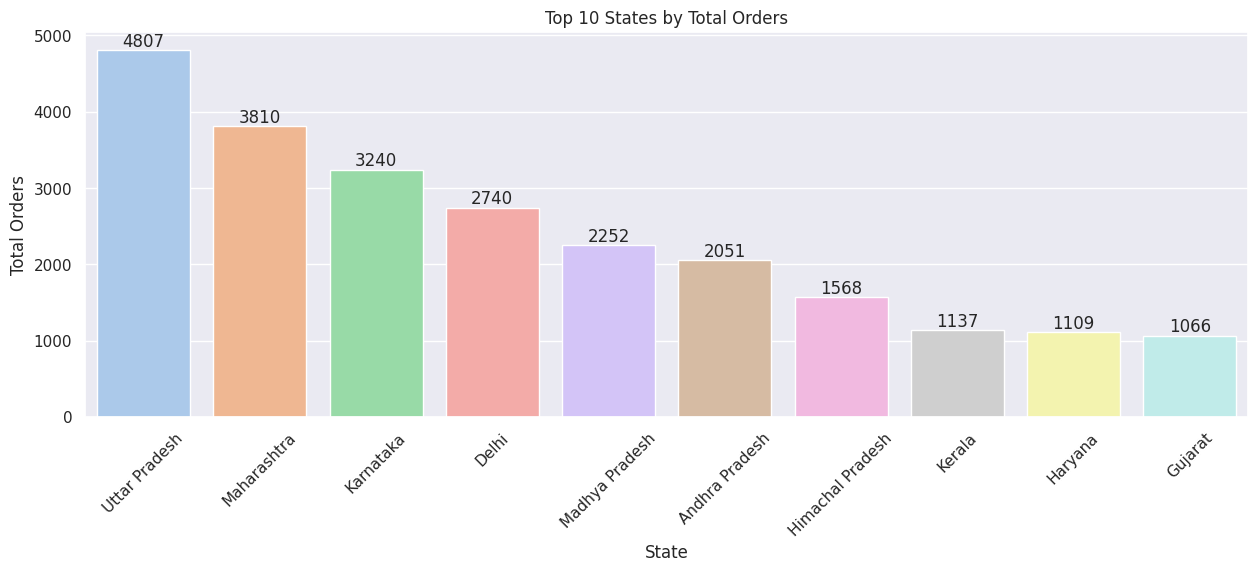

In [47]:
# Total number of orders from top 10 states

sales_state_orders = (
    df.groupby('State', as_index=False)['Orders']
      .sum()
      .sort_values(by='Orders', ascending=False)
      .head(10)
)

sns.set(rc={'figure.figsize': (15, 5)})

ax = sns.barplot(
    data=sales_state_orders,
    x='State',
    y='Orders',
    palette='pastel',
    hue='State',
    legend=False
)

for bars in ax.containers:
    ax.bar_label(bars, fmt='%.0f')

plt.title('Top 10 States by Total Orders')
plt.xlabel('State')
plt.ylabel('Total Orders')
plt.xticks(rotation=45)
plt.show()

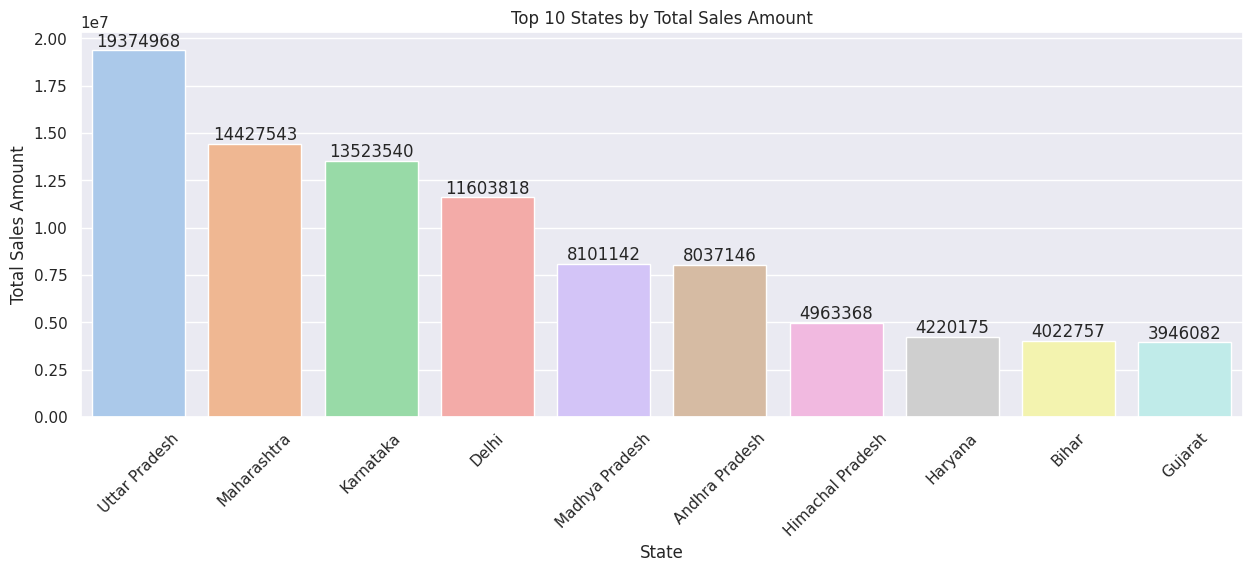

In [48]:
# Total sales amount from top 10 states

sales_state = (
    df.groupby('State', as_index=False)['Amount']
      .sum()
      .sort_values(by='Amount', ascending=False)
      .head(10)
)

sns.set(rc={'figure.figsize': (15, 5)})

ax = sns.barplot(
    data=sales_state,
    x='State',
    y='Amount',
    palette='pastel',
    hue='State',
    legend=False
)

for bars in ax.containers:
    ax.bar_label(bars, fmt='%.0f')

plt.title('Top 10 States by Total Sales Amount')
plt.xlabel('State')
plt.ylabel('Total Sales Amount')
plt.xticks(rotation=45)
plt.show()

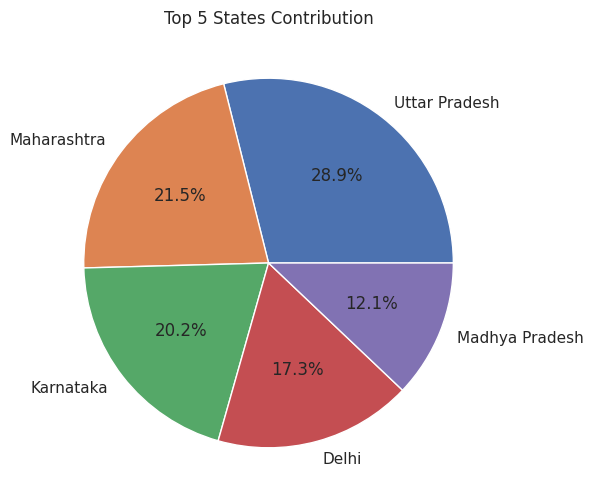

In [49]:
state_sales = df.groupby('State')['Amount'].sum().sort_values(ascending=False).head(5)

plt.figure(figsize=(6,6))
plt.pie(state_sales, labels=state_sales.index, autopct='%1.1f%%')
plt.title('Top 5 States Contribution')
plt.show()

*From above graphs we can see that most of the orders & total sales/amount are from Uttar Pradesh, Maharashtra and Karnataka respectively*


### Marital Status

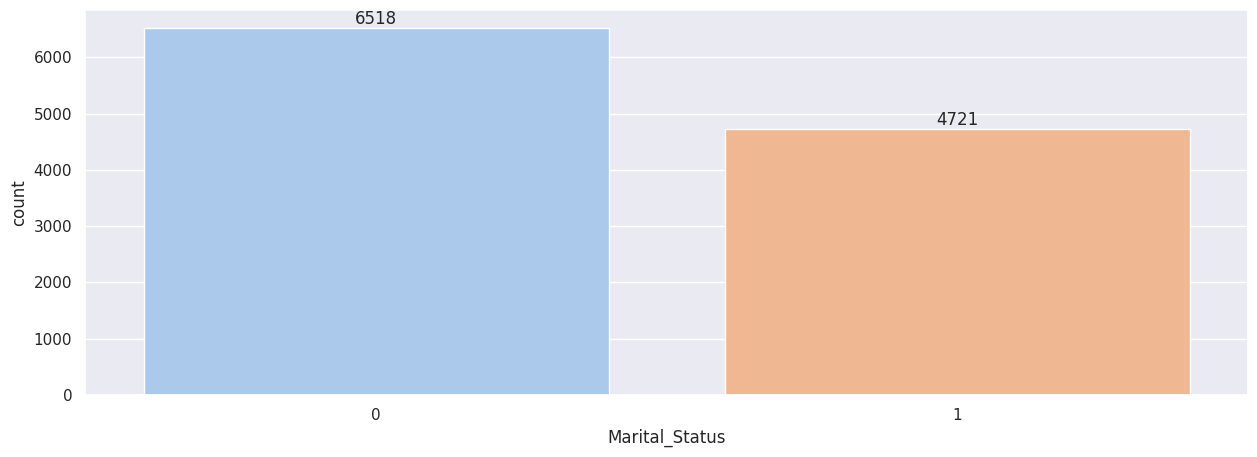

In [50]:
ax = sns.countplot(data = df, x='Marital_Status', hue='Marital_Status', palette='pastel', legend=False)

sns.set(rc={'figure.figsize':(5,5)})
for bars in ax.containers:
    ax.bar_label(bars)

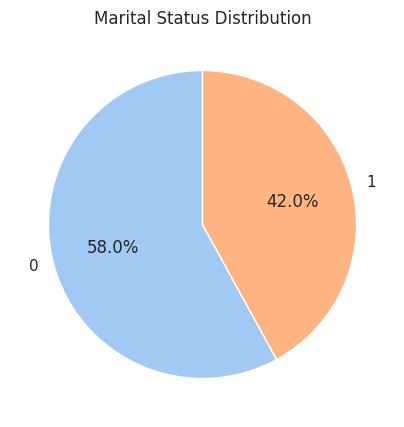

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set figure size
sns.set(rc={'figure.figsize':(5,5)})

# Count values
marital_counts = df['Marital_Status'].value_counts()

# Get pastel colors
colors = sns.color_palette('pastel')

# Plot pie chart
plt.pie(
    marital_counts,
    labels=marital_counts.index,
    autopct='%1.1f%%',
    colors=colors,
    startangle=90
)

plt.title('Marital Status Distribution')
plt.show()

In [52]:
df.groupby(['Marital_Status', 'Gender'], as_index=False)['Amount'].sum().sort_values(by='Amount', ascending=False)

,Marital_Status,Gender,Amount
0,0,F,43786646
2,1,F,30549207
1,0,M,18338738
3,1,M,13574538


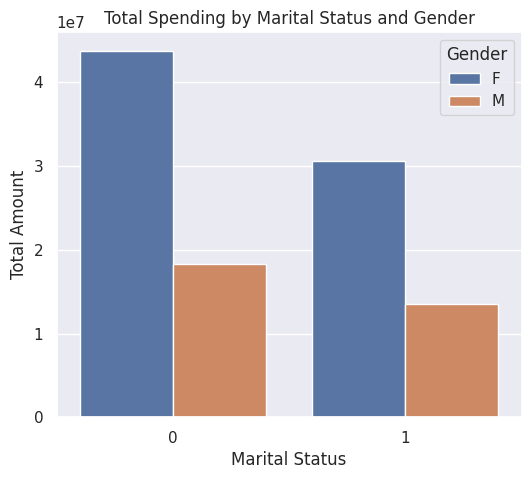

In [53]:
sales_state = (
    df.groupby(['Marital_Status', 'Gender'], as_index=False)['Amount']
      .sum()
      .sort_values(by='Amount', ascending=False)
)

sns.set(rc={'figure.figsize': (6, 5)})

sns.barplot(
    data=sales_state,
    x='Marital_Status',
    y='Amount',
    hue='Gender'
)

plt.title('Total Spending by Marital Status and Gender')
plt.xlabel('Marital Status')
plt.ylabel('Total Amount')
plt.show()

*From above graphs we can see that most of the buyers are married (women) and they have high purchasing power*

### Occupation

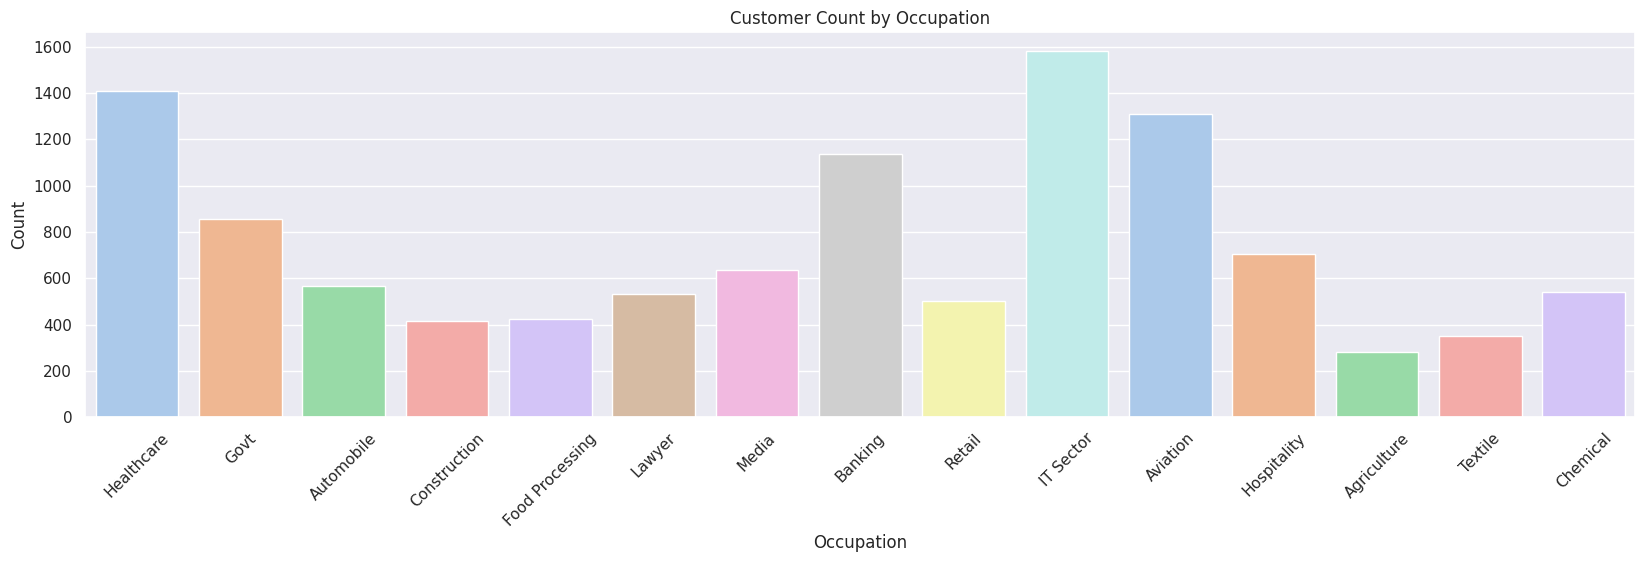

In [54]:

sns.set(rc={'figure.figsize': (20, 5)})

ax = sns.countplot(
    data=df,
    x='Occupation', hue='Occupation', legend=False,
    palette='pastel'
)

plt.title('Customer Count by Occupation')
plt.xlabel('Occupation')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

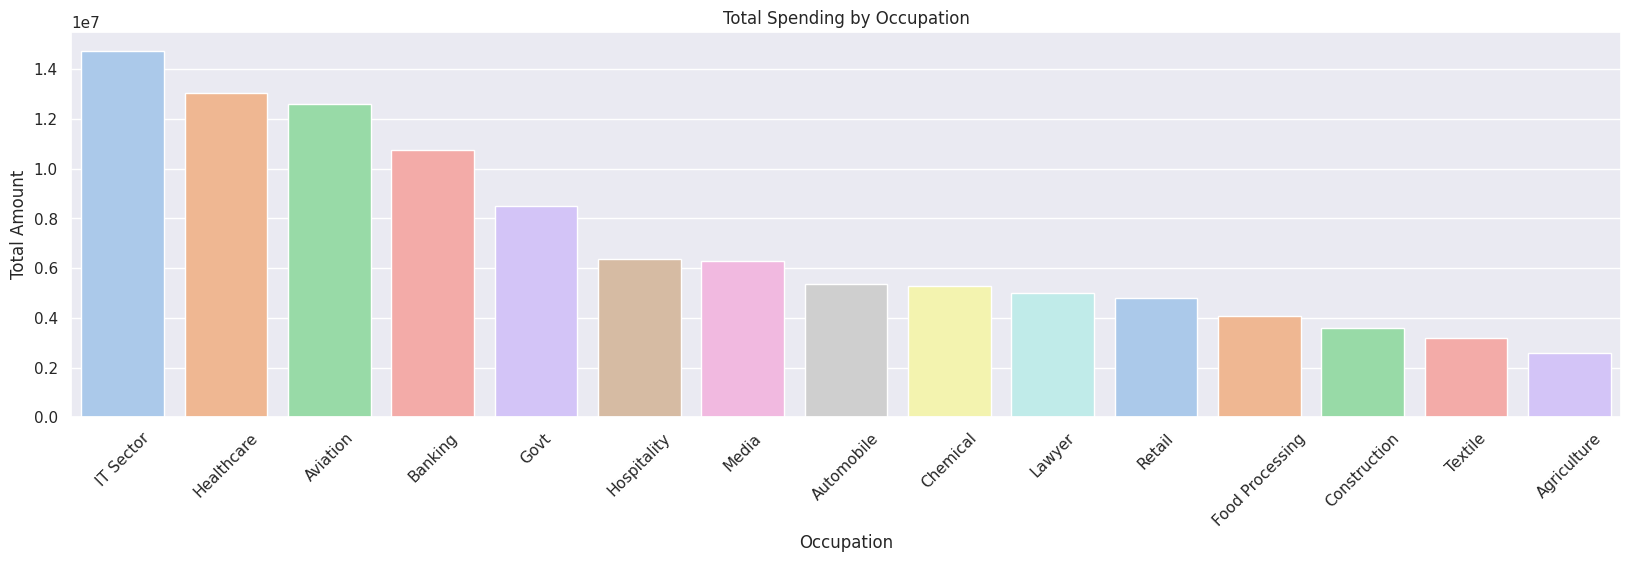

In [55]:
sales_occupation = (
    df.groupby('Occupation', as_index=False)['Amount']
      .sum()
      .sort_values(by='Amount', ascending=False)
)

sns.set(rc={'figure.figsize': (20, 5)})

ax = sns.barplot(
    data=sales_occupation,
    x='Occupation',
    y='Amount',
    palette='pastel',
    hue='Occupation',
    legend=False
)

plt.title('Total Spending by Occupation')
plt.xlabel('Occupation')
plt.ylabel('Total Amount')
plt.xticks(rotation=45)
plt.show()

*From above graphs we can see that most of the buyers are working in IT, Healthcare and Aviation sector*

### Product Category

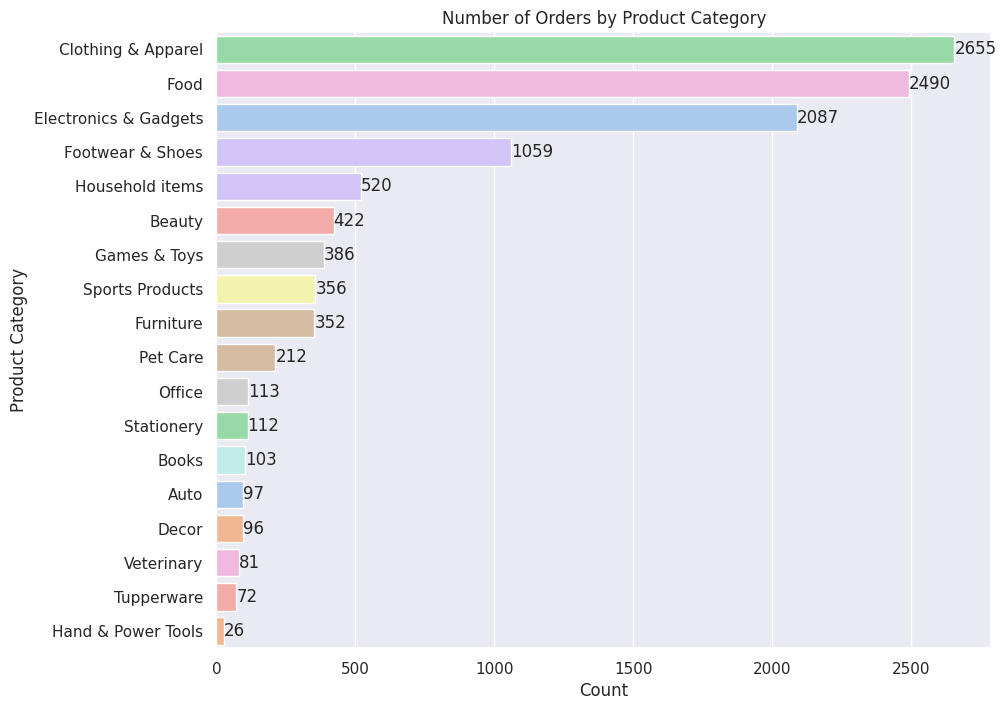

In [56]:
sns.set(rc={'figure.figsize': (10, 8)})

ax = sns.countplot(
    data=df,
    y='Product_Category', hue='Product_Category', legend=False,
    order=df['Product_Category'].value_counts().index,
    palette='pastel'
)

for bars in ax.containers:
    ax.bar_label(bars)

plt.title('Number of Orders by Product Category')
plt.xlabel('Count')
plt.ylabel('Product Category')
plt.show()

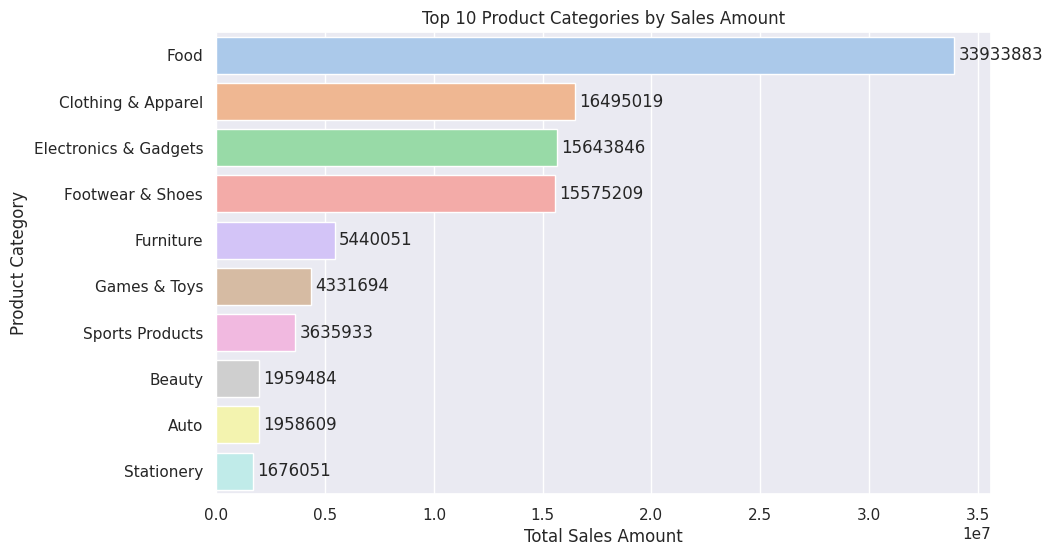

In [57]:
sales_prod_cat = (
    df.groupby('Product_Category', as_index=False)['Amount']
      .sum()
      .sort_values(by='Amount', ascending=False)
      .head(10)
)

sns.set(rc={'figure.figsize': (10, 6)})

ax = sns.barplot(
    data=sales_prod_cat,
    x='Amount',
    y='Product_Category', hue='Product_Category', legend=False,
    palette='pastel'
)

for bars in ax.containers:
    ax.bar_label(bars, fmt='%.0f', padding=3)

plt.title('Top 10 Product Categories by Sales Amount')
plt.xlabel('Total Sales Amount')
plt.ylabel('Product Category')
plt.show()

*From above graphs we can see that most of the sold products are from Food, Clothing and Electronics category*

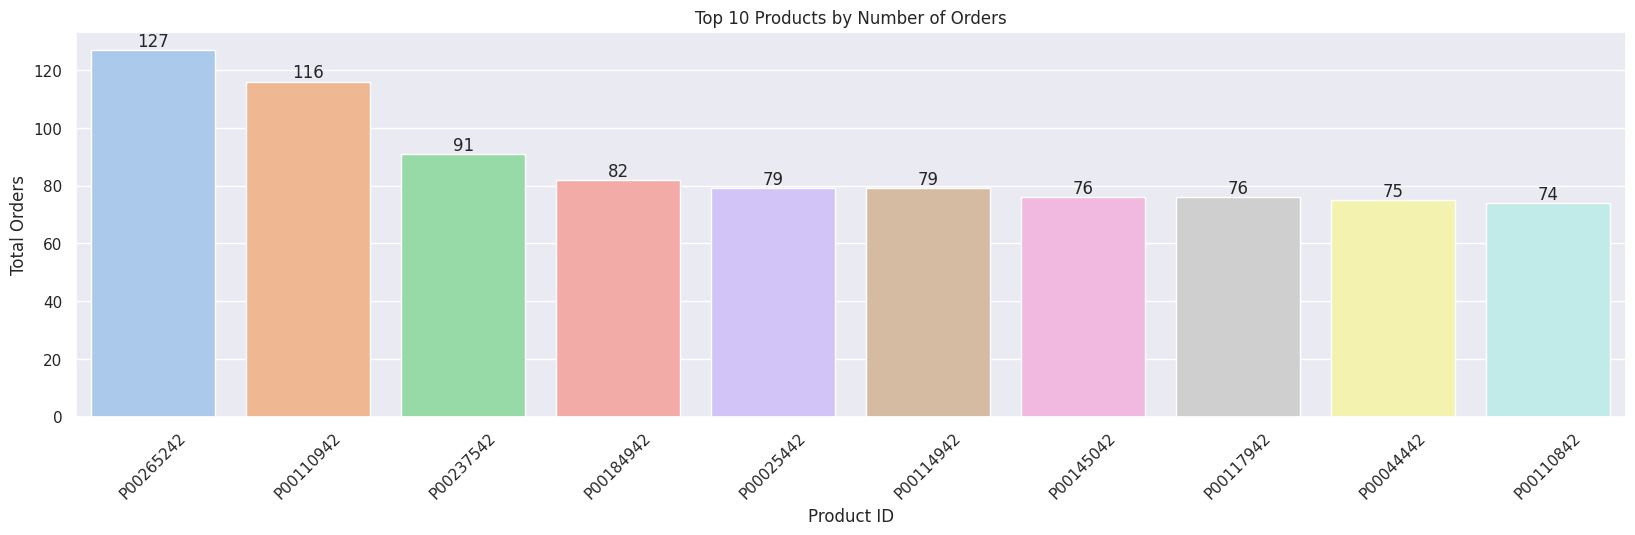

In [58]:
top_products_orders = (
    df.groupby('Product_ID', as_index=False)['Orders']
      .sum()
      .sort_values(by='Orders', ascending=False)
      .head(10)
)

sns.set(rc={'figure.figsize': (20, 5)})

ax = sns.barplot(
    data=top_products_orders,
    x='Product_ID',
    y='Orders',
    palette='pastel',
    hue='Product_ID',
    legend=False
)

for bars in ax.containers:
    ax.bar_label(bars, fmt='%.0f')

plt.title('Top 10 Products by Number of Orders')
plt.xlabel('Product ID')
plt.ylabel('Total Orders')
plt.xticks(rotation=45)
plt.show()

---
# Advanced Analysis

The sections above replicate and extend a standard EDA. The three sections below go beyond it: a customer-level **Frequency–Monetary segmentation**, a **market-basket** view of which product categories are bought together, and a **predictive model** for high-value orders. Together they turn the descriptive findings into something closer to a decision tool.

> **Note on RFM:** A full RFM (Recency, Frequency, Monetary) analysis is not possible here because the dataset has **no order date / timestamp**. Recency cannot be computed, so the segmentation below uses **Frequency and Monetary only (FM)**, which the available fields fully support.

## 1. Customer Segmentation (Frequency–Monetary)

Each row is a transaction; `User_ID` links transactions to customers. We aggregate to the customer level — total `Orders` (Frequency) and total `Amount` (Monetary) — then score each customer into quartiles and combine the scores into four intuitive segments.

In [59]:
# Aggregate transactions to the customer level
customer = (
    df.groupby('User_ID')
      .agg(Frequency=('Orders', 'sum'),
           Monetary=('Amount', 'sum'),
           Transactions=('Product_ID', 'count'))
      .reset_index()
)

# Quartile scores (1 = lowest, 4 = highest). rank() breaks ties so qcut gets equal bins.
customer['F_score'] = pd.qcut(customer['Frequency'].rank(method='first'), 4, labels=[1, 2, 3, 4]).astype(int)
customer['M_score'] = pd.qcut(customer['Monetary'], 4, labels=[1, 2, 3, 4]).astype(int)
customer['FM_score'] = customer['F_score'] + customer['M_score']

def label_segment(score):
    if score >= 7:
        return 'Champions'
    elif score >= 5:
        return 'Loyal'
    elif score >= 3:
        return 'Potential'
    else:
        return 'At Risk'

customer['Segment'] = customer['FM_score'].apply(label_segment)
customer.head()

,User_ID,Frequency,Monetary,Transactions,F_score,M_score,FM_score,Segment
0,1000001,1,3977,1,1,1,2,At Risk
1,1000002,3,7098,1,1,1,2,At Risk
2,1000003,6,23714,2,3,3,6,Loyal
3,1000004,3,30381,2,1,3,4,Potential
4,1000005,4,27667,2,2,3,5,Loyal


In [60]:
# Segment summary: how many customers, and how much revenue, each segment represents
segment_summary = (
    customer.groupby('Segment')
            .agg(Customers=('User_ID', 'count'),
                 Avg_Monetary=('Monetary', 'mean'),
                 Total_Revenue=('Monetary', 'sum'))
            .round(0)
            .sort_values('Total_Revenue', ascending=False)
)
segment_summary['Revenue_%'] = (segment_summary['Total_Revenue'] / customer['Monetary'].sum() * 100).round(1)
segment_summary['Customer_%'] = (segment_summary['Customers'] / len(customer) * 100).round(1)
segment_summary

,Customers,Avg_Monetary,Total_Revenue,Revenue_%,Customer_%
Segment,,,,,
Champions,1098,60526.0,66457904,62.5,29.3
Loyal,973,23342.0,22711882,21.4,25.9
Potential,1157,12066.0,13960189,13.1,30.8
At Risk,524,5953.0,3119154,2.9,14.0


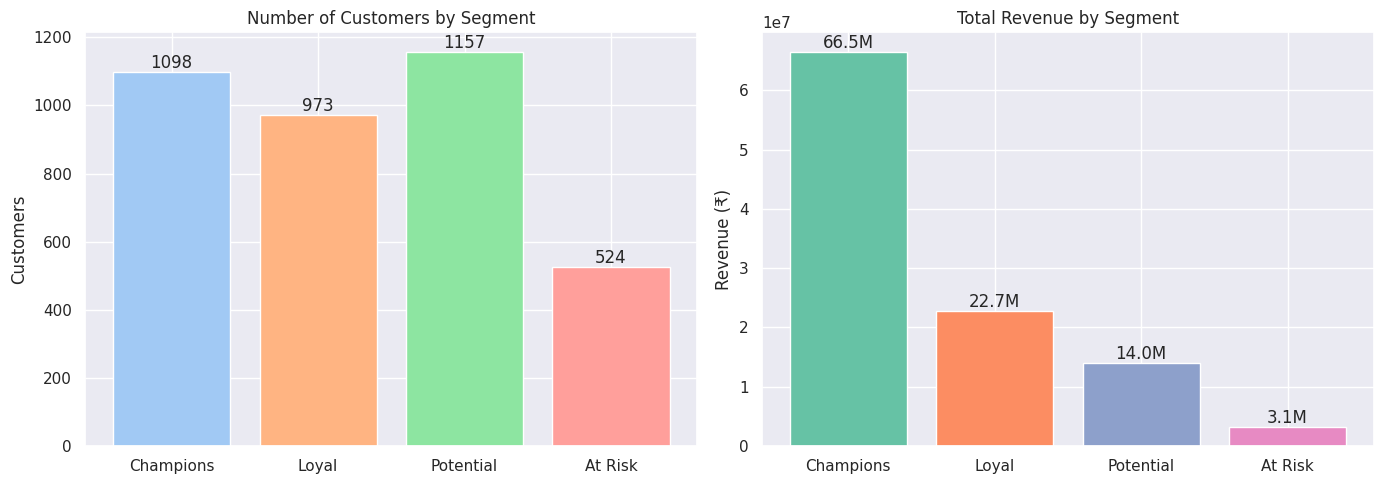

In [61]:
# Visualize the customer-count vs revenue-share imbalance across segments
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
order = ['Champions', 'Loyal', 'Potential', 'At Risk']

seg_counts = customer['Segment'].value_counts().reindex(order)
seg_rev = customer.groupby('Segment')['Monetary'].sum().reindex(order)

axes[0].bar(seg_counts.index, seg_counts.values, color=sns.color_palette('pastel'))
axes[0].set_title('Number of Customers by Segment')
axes[0].set_ylabel('Customers')
for i, v in enumerate(seg_counts.values):
    axes[0].text(i, v, str(int(v)), ha='center', va='bottom')

axes[1].bar(seg_rev.index, seg_rev.values, color=sns.color_palette('Set2'))
axes[1].set_title('Total Revenue by Segment')
axes[1].set_ylabel('Revenue (₹)')
for i, v in enumerate(seg_rev.values):
    axes[1].text(i, v, f'{v/1e6:.1f}M', ha='center', va='bottom')

plt.tight_layout()
plt.show()

**Insight.** The **Champions** segment is the engine of the business: roughly **29% of customers generate ~62% of revenue**, while the **At Risk** group (~14% of customers) contributes under 3%. Retention spend should concentrate on Champions and Loyal customers; the Potential group is the most promising target for up-sell campaigns to move them up a tier.

## 2. Market-Basket Analysis (Category Co-Purchase)

Which product categories are bought together by the same customer? We build a "basket" of distinct categories per `User_ID`, then count how often each pair of categories co-occurs. **Support %** is the share of all customers whose basket contains that pair.

In [62]:
from itertools import combinations
from collections import Counter

# One basket of unique categories per customer
baskets = df.groupby('User_ID')['Product_Category'].apply(lambda x: sorted(set(x)))

# Count every co-occurring category pair
pair_counts = Counter()
for basket in baskets:
    for pair in combinations(basket, 2):
        pair_counts[pair] += 1

n_customers = df['User_ID'].nunique()
basket_pairs = pd.DataFrame(pair_counts.most_common(10), columns=['Category_Pair', 'Co_Purchase_Count'])
basket_pairs['Support_%'] = (basket_pairs['Co_Purchase_Count'] / n_customers * 100).round(1)
basket_pairs

,Category_Pair,Co_Purchase_Count,Support_%
0,"(Clothing & Apparel, Food)",780,20.8
1,"(Clothing & Apparel, Electronics & Gadgets)",651,17.4
2,"(Electronics & Gadgets, Food)",630,16.8
3,"(Clothing & Apparel, Footwear & Shoes)",423,11.3
4,"(Food, Footwear & Shoes)",386,10.3
5,"(Electronics & Gadgets, Footwear & Shoes)",330,8.8
6,"(Food, Household items)",238,6.3
7,"(Clothing & Apparel, Household items)",234,6.2
8,"(Beauty, Clothing & Apparel)",204,5.4
9,"(Beauty, Food)",204,5.4


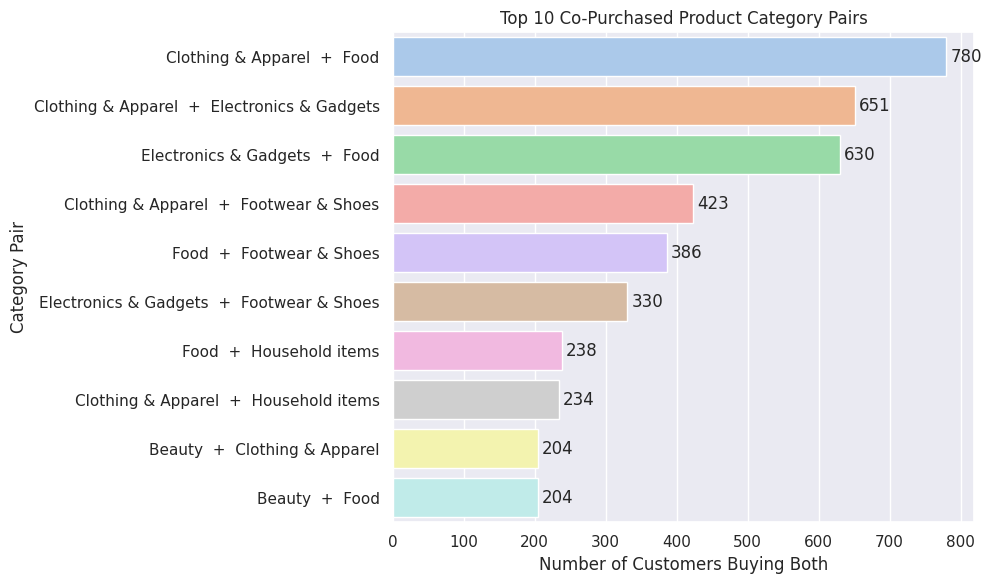

In [63]:
# Plot the top category pairs bought together
plt.figure(figsize=(10, 6))
labels = [f'{a}  +  {b}' for a, b in basket_pairs['Category_Pair']]
ax = sns.barplot(x=basket_pairs['Co_Purchase_Count'], y=labels, hue=labels, palette='pastel', legend=False)
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=3)
plt.title('Top 10 Co-Purchased Product Category Pairs')
plt.xlabel('Number of Customers Buying Both')
plt.ylabel('Category Pair')
plt.tight_layout()
plt.show()

**Insight.** The strongest affinities all involve the three best-selling categories: **Clothing & Apparel + Food** appears in ~21% of customer baskets, followed by **Clothing + Electronics** and **Electronics + Food**. These pairs are natural candidates for **bundle offers, cross-sell recommendations, and combined festive promotions** ("buy Clothing, get a Food/Electronics discount").

## 3. Predicting High-Value Orders

Can we predict whether an order will be **high-value** before it completes? We define a high-value order as one in the **top 25% of `Amount`**, then train a Random Forest classifier on demographic, geographic, occupation, and product-category features.

A quick check first: `Amount` and `Orders` have near-zero correlation (≈ −0.01), so order count does **not** leak the target — the model must learn from the customer and product attributes.

In [64]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, classification_report, ConfusionMatrixDisplay

# Define target: top quartile of order value
threshold = df['Amount'].quantile(0.75)
df['HighValue'] = (df['Amount'] >= threshold).astype(int)
print(f"High-value threshold (75th percentile): ₹{int(threshold)}")
print(f"High-value order rate: {df['HighValue'].mean():.1%}")

# Features (note: 'Amount' is excluded — it defines the target)
features = ['Gender', 'Age Group', 'Marital_Status', 'State', 'Zone',
            'Occupation', 'Product_Category', 'Orders', 'Age']
X = pd.get_dummies(
    df[features],
    columns=['Gender', 'Age Group', 'Marital_Status', 'State', 'Zone', 'Occupation', 'Product_Category'],
    drop_first=True
)
y = df['HighValue']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)
print(f"Training rows: {len(X_train)} | Test rows: {len(X_test)} | Features: {X.shape[1]}")

High-value threshold (75th percentile): ₹12675
High-value order rate: 25.0%
Training rows: 8429 | Test rows: 2810 | Features: 60


In [65]:
# Train the classifier (class_weight balances the 75/25 split)
model = RandomForestClassifier(
    n_estimators=200, max_depth=12, random_state=42,
    n_jobs=-1, class_weight='balanced'
)
model.fit(X_train, y_train)

y_proba = model.predict_proba(X_test)[:, 1]
y_pred = model.predict(X_test)

print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.3f}\n")
print(classification_report(y_test, y_pred, target_names=['Standard', 'High-Value'], digits=3))

ROC-AUC: 0.879

              precision    recall  f1-score   support

    Standard      0.991     0.748     0.853      2107
  High-Value      0.565     0.979     0.716       703

    accuracy                          0.806      2810
   macro avg      0.778     0.864     0.784      2810
weighted avg      0.884     0.806     0.819      2810



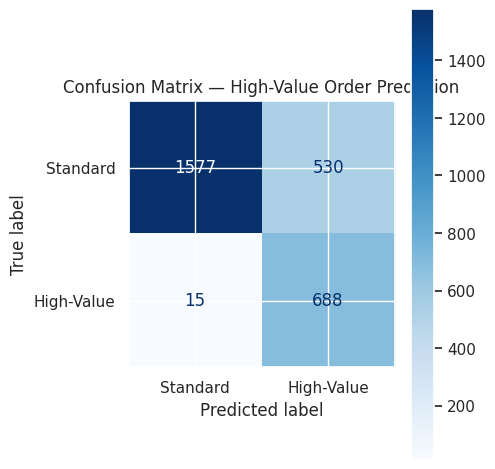

In [66]:
# Confusion matrix
fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=['Standard', 'High-Value'], cmap='Blues', ax=ax
)
plt.title('Confusion Matrix — High-Value Order Prediction')
plt.tight_layout()
plt.show()

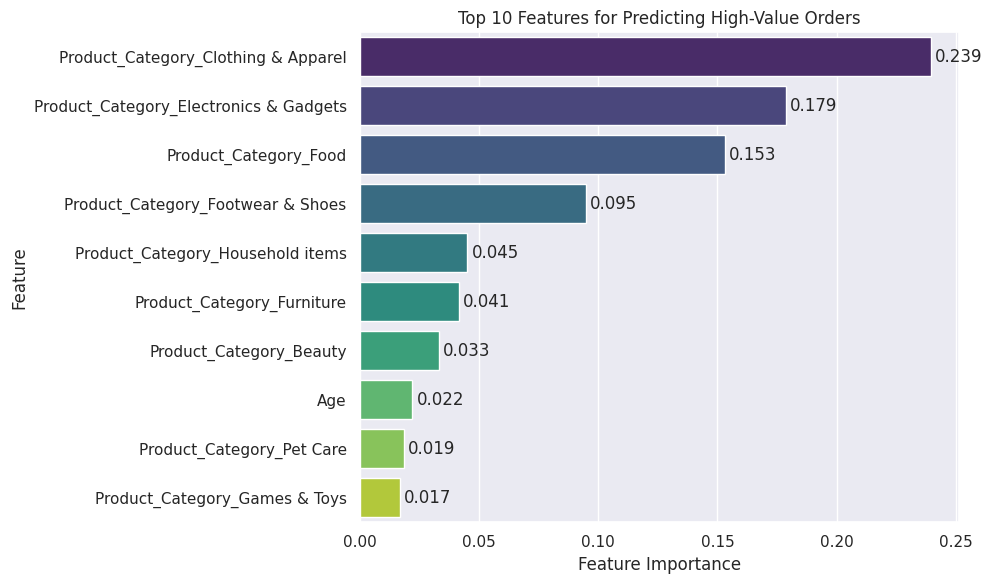

In [67]:
# Which features drive a high-value order?
importances = (
    pd.Series(model.feature_importances_, index=X.columns)
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=importances.values, y=importances.index, hue=importances.index, palette='viridis', legend=False)
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=3)
plt.title('Top 10 Features for Predicting High-Value Orders')
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

**Insight.** The model separates high-value from standard orders well (**ROC-AUC ≈ 0.88**), with strong recall on the high-value class. **Product category is overwhelmingly the strongest predictor** — Clothing & Apparel, Electronics & Gadgets, and Food dominate the importance ranking, while demographics and geography add only marginal signal. This reinforces the EDA conclusion: **what** a customer buys drives order value far more than **who** they are. Practically, the model could flag likely high-value baskets at checkout for targeted offers or priority fulfilment.

## Conclusion & Key Insights

This analysis explored **11,239 transactions** (after cleaning) from a retail sales dataset, totalling **₹10.62 crore in revenue** across **27,981 orders**, for an **average order value of ≈ ₹3,797**. The cleaning step removed two empty columns (`Status`, `unnamed1`) and 12 rows with missing `Amount` values.

### Customer profile of the highest-value buyer

| Dimension | Leading segment | Share of revenue |
|---|---|---|
| Gender | Female | **70.0%** |
| Age group | 26–35 | **40.1%** |
| Marital status | Married | ≈ 58% |
| Top state | Uttar Pradesh | 18.2% |
| Top occupation | IT Sector | 13.9% |
| Top category | Food | 31.9% |

### What the numbers say

- **Women drive the market.** Female customers account for 70% of total sales — more than twice the revenue of male customers — so demographic targeting and creative should lead with a female audience.
- **Spending concentrates in mid-career adults.** The 26–35 group alone generates 40% of revenue; together with 36–45, the 26–45 band covers roughly 61% of all sales.
- **Geography is top-heavy.** The top five states (Uttar Pradesh, Maharashtra, Karnataka, Delhi, Andhra Pradesh) contribute about 63% of revenue, making them the natural priority for inventory and regional campaigns.
- **Occupation skews to salaried professionals.** IT, Healthcare and Aviation are the three largest occupation groups by spend, consistent with higher disposable income.
- **Food leads category sales.** Food alone is ~32% of revenue, followed by Clothing & Apparel, Footwear and Electronics — each in the 15% range.
- **Spend is not driven by age or order count.** The correlation between `Amount` and both `Age` (0.03) and `Orders` (−0.01) is effectively zero, so purchase value is better explained by the categorical segments above than by these continuous variables.

### Business recommendation

The single most valuable customer this season is a **married woman aged 26–35, living in UP / Maharashtra / Karnataka, working in IT, Healthcare or Aviation, buying Food, Clothing and Electronics.** Marketing spend, stock allocation and personalised offers should be weighted toward this segment, while the near-zero `Amount`–`Orders` correlation suggests growth should come from acquiring more high-value customers rather than pushing larger basket sizes on existing ones.

### Advanced analysis adds three layers beyond the EDA

- **Customer segmentation (FM):** ~29% of customers (Champions) generate ~62% of revenue — a textbook Pareto pattern that should anchor retention spend.
- **Market basket:** Clothing+Food, Clothing+Electronics and Electronics+Food are the strongest co-purchase pairs, ideal for bundling and cross-sell.
- **Predictive model:** a Random Forest predicts high-value (top-25%) orders at **ROC-AUC ≈ 0.88**, with product category — not demographics — as the dominant driver.

### Limitations & next steps

- The dataset is a single-season snapshot with **no dates**, so Recency (full RFM) and time-trend analysis are not possible — the segmentation uses Frequency + Monetary only.
- A proper market-basket algorithm (Apriori / FP-Growth) with lift and confidence would refine the co-purchase rules beyond simple co-occurrence support.
- The classifier could be compared against logistic regression / gradient boosting and validated with cross-validation and calibration before any production use.

---
*Project type: exploratory data analysis. Dataset and original project structure adapted from a publicly available sales-analysis tutorial by Rishabh Mishra; this version adds a KPI summary, contribution-percentage analysis, refined visualizations, and an expanded insights section.*